# Exercise 2

Deadline 18.11.2025

Anna Bütfering

Lea Neumann

Juan Provencio

---
## Two dimensional data with bottleneck

Use pytorch to implement and train an autoencoder. The autoencoder's constructor should have
four arguments:

**input_size**: the data dimension (so that we can later reuse the autoencoder in task 3)

**bottleneck_size**: the code dimension (also for reuse in task 3 in the present task the code dimension is always 1)

**hidden_size**: the dimension of the hidden layers (should be larger than the data dimension!)

**layers**: the number of hidden layers

#### Packages & visualisation functions

In [2]:
# Torch
#
!pip install torch
import torch 
from torch import nn, optim
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from scipy.stats import norm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 217.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 349.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 291.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 268.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 373.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 168.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 234.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 397.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 272.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 144.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 174.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
''' Plotting functions for Ex01 '''
# Function for visualising the results in 1.1:
def plot1_1(model, results, title, label, label_index):
    fig, axes = plt.subplots(1, 2)
    fig.suptitle(title, fontsize=26)
    
    # Plot MSE loss for different parameters
    for res in results:
        params, train_losses, _ = res
        axes[0].plot(train_losses, label=f"{label}: {params[label_index]}")
    axes[0].set_xlabel("Iterations")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()
    axes[0].loglog()
    
    # Plot final reconstruction
    # Get final output
    final_epoch, X_batch, decoded = model.outputs[-1]
    axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = colors[5])
    for i in range(len(results)):
        final_epoch, X_batch, decoded = results[i][2]
        axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                        label=f"(Epochs: {results_tss[i][0][label_index]})", 
                        color = colors[i])
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show() 

# Function for visualising the results in 1.2:
def plot1_2(model, results, title):
    
    #Print out average and variance of MSE:
    all_avg = []
    print(f"Set: Mean, Std")
    for res in results:
        TS, _, train_losses, _ = res
        avg = np.mean(train_losses)
        all_avg.append(avg)
        std = np.std(train_losses)
        print(f"{TS}: {avg:.4f} {std:.4f}")
    total_mean = np.mean(all_avg)
    total_std = np.std(all_avg)
    print(f"Average MSE over all data sets: {total_mean:.4f} with a standard deviation of {total_std:.4f}")
    
    fig, axes = plt.subplots(1, 3)
    fig.suptitle(title, fontsize=26)
    
    # Plot MSE loss for different training sets: 
    for res in results:
        TS, params, train_losses, _ = res
        axes[1].plot(train_losses, label=f"Training set: {TS}")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("MSE Loss")
    #axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols= len(results[:][0]))
    axes[1].loglog()

    
    # Plot final reconstruction
    # Get final output
    final_epoch, X_batch, decoded = model.outputs[-1]
    for i in range(len(results)):
        final_epoch, X_batch, decoded = results[i][3]
        axes[0].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                        label=f"(Training set: {results[i][0]})", 
                        color = colors[i])
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))

    
    # Plot Boxplots of MSE:
    data = []
    labels = []
    for res in results:
        TS, _, train_losses, __ = res
        data.append(np.array(train_losses).flatten())
        labels.append(TS)
    axes[2].boxplot(data, tick_labels= labels, medianprops=dict(color='black', linewidth=2))#, color = colors)
    axes[2].set_yscale('log')
    axes[2].set_xlabel(None)
    axes[2].set_ylabel("MSE loss")
    
    plt.tight_layout()
    plt.show() 

---
### Autoencoder Class Implementation

In [4]:
# Dataset from two moons:
X, y = make_moons(n_samples=125000, noise=0.1, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
#y = torch.tensor(y, dtype=torch.long)

# Split into train and test sets:
X_test, X_train = train_test_split(X, test_size=0.2, random_state=42)

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_size, bottleneck_size, hidden_size, layers):
        # Initialize AE with required parameters
        self.input_size = input_size
        self.bottleneck_size = bottleneck_size
        self.hidden_size = hidden_size
        self.layers = layers
        # Save hyperparameters
        self.lr = 0.001
        # Save results
        self.train_losses = []
        self.test_losses = []
        self.outputs = []

        # Structure: [ENCODER -> {BOTTLENECK] -> DECODER}

        # First call super constructor
        super(Autoencoder, self).__init__()

        # Encoder
        ## Initial layer input -> hidden
        self.encoder = nn.ModuleList()
        self.encoder.append(nn.Linear(input_size, hidden_size))
        self.encoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.encoder.append(nn.Linear(hidden_size, hidden_size))
            self.encoder.append(nn.ReLU())
        ## Final layer hidden -> bottleneck
        self.encoder.append(nn.Linear(hidden_size, bottleneck_size))

        # Decoder
        ## Initial layer bottleneck -> hidden
        self.decoder = nn.ModuleList()
        self.decoder.append(nn.Linear(bottleneck_size, hidden_size))
        self.decoder.append(nn.ReLU())
        ## Hidden layers hidden -> hidden
        for _ in range(layers - 1):
            self.decoder.append(nn.Linear(hidden_size, hidden_size))
            self.decoder.append(nn.ReLU())
        ## Final layer hidden -> output
        self.decoder.append(nn.Linear(hidden_size, input_size))


    def forward(self, x):
        # Forward pass
        for layer in self.encoder:
            x = layer(x)
        for layer in self.decoder:
            x = layer(x)
        decoded = x
        return decoded

    def train_autoencoder(self, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
        # Loss function
        loss_function = nn.MSELoss()
        # Optimizer
        optimizer = optim.Adam(self.parameters(), lr = learning_rate)
        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)

        for epoch in tqdm(range(n_epochs)):
            for X_batch in loader:
                #print(X_batch)
                # Make forward pass
                decoded = self.forward(X_batch)
                # Compute loss
                loss = loss_function(decoded, X_batch)
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded))

    #Functions for 1.3: Training of a GMM on the encoded data (Z) 
    '''
    Only difference in forwardZ() and train_autoencoderZ() is that the encoded data points are returned by the functions.
    '''
    def forwardZ(self, x):
        # Forward pass
        for layer in self.encoder:
            x = layer(x)
        encoded = x
        for layer in self.decoder:
            x = layer(x)
        decoded = x
        return decoded, encoded # Z is returned as well as decoded data points.

    def train_autoencoderZ(self, X_train, training_set_size, mini_batch_size, n_epochs, learning_rate):
        # Loss function
        loss_function = nn.MSELoss()
        # Optimizer
        optimizer = optim.Adam(self.parameters(), lr = learning_rate)
        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)
        for epoch in tqdm(range(n_epochs)):
            for X_batch in loader:
                #print(X_batch)
                # Make forward pass
                decoded, encoded = self.forwardZ(X_batch)
                # Compute loss
                loss = loss_function(decoded, X_batch)
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded, encoded))

    def gmmGenerate(self, components=2):
        '''
        This function... 
        - gets the decoded and encoded data points from a trained model. 
        - trains a GMM with n components (default 2) on the one-dimensional encoded data.
        - samples generated, encoded data points from the GMM.
        - decodes these new data points via the AE.
        - returns the reconstructed (AE-encoded and -decoded) and the generated (decoded GMM-samples) data.
        '''
        #Get encoded and reconstructed data points:
        _, _, reconstructed, encoded = self.outputs[-1]
        z_ = encoded[:,0].detach().numpy()

        #Fit GMM to code dist:
        z = z_.reshape(-1, 1)
        gmm = GaussianMixture(n_components = components).fit(z)
        
        #Sample from GMM:
        z_samples = gmm.sample(n_samples= len(z_))
        z_samples = z_samples[0] #ignore y labels in columns [1]
        z_samples = torch.tensor(z_samples, dtype=torch.float32) 

        # Decode generated data:
        for layer in self.decoder:
            z_samples = layer(z_samples)
        generated = z_samples
        
        return reconstructed, generated

### 1. Investigate systematically different hyperparameters:

Starting from `(training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers) = (1000, 32, 10, 0.001, 4, 2)`, we want to test the influence of the different parameters. We'll compute the Mean Squared Error (MSE) to determine the performance of the different parameter configurations. Since a 6 dimensional phase space is very impractical to explore and perform a grid search for the optimal solution, we'll explore every axis individually and from there converge onto a good solution.

In [34]:
# 1 Investigate the influence of training set size given fixed other hyperparameters
hyperparameters_tss = [(1000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                   (10000, 32, 10, 0.001, 4, 2),
                   (50000, 32, 10, 0.001, 4, 2), 
                   (100000, 32, 10, 0.001, 4, 2)]

results_tss = []
for params in hyperparameters_tss:
    print(f"Training with training set size: {params[0]}")
    # Create model
    model_tss = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_tss.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))

Training with training set size: 1000


100%|██████████| 10/10 [00:00<00:00, 50.51it/s]


Training with training set size: 10000


100%|██████████| 10/10 [00:01<00:00,  5.25it/s]


Training with training set size: 50000


100%|██████████| 10/10 [00:04<00:00,  2.10it/s]


Training with training set size: 100000


100%|██████████| 10/10 [00:04<00:00,  2.12it/s]


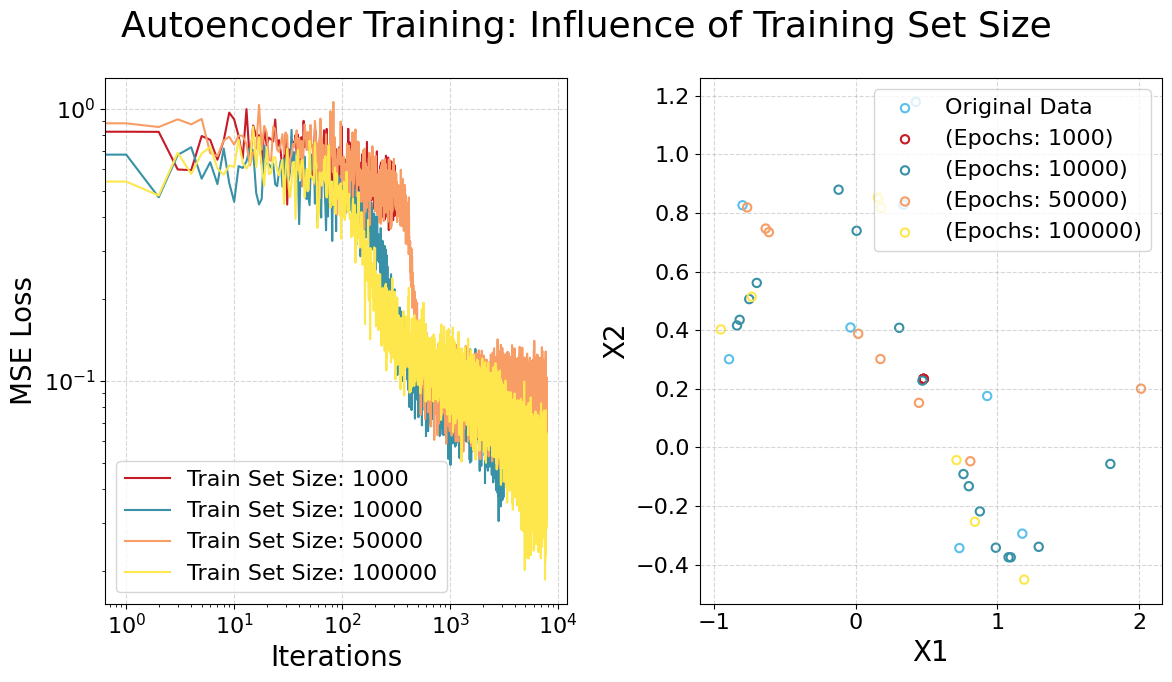

In [36]:
# Plot MSE loss for different training set sizes
title = "Autoencoder Training: Influence of Training Set Size"
plot1_1(model_tss, results_tss, title, label="Train Set Size", label_index= 0 )

Simply increasing the test size does obviously no good if the underlying network architecture is poor.

In [37]:
# 1 Investigate the influence of number of epochs given fixed other hyperparameters
hyperparameters_n_epochs = [(2000, 32, 10, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                            (2000, 32, 100, 0.001, 4, 2),
                            (2000, 32, 1000, 0.001, 4, 2),
                            (2000, 32, 5000, 0.001, 4, 2)]

results_n_epochs = []
for params in hyperparameters_n_epochs:
    print(f"Training with training set size: {params[0]}, epochs: {params[2]}")
    # Create model
    model_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save results
    results_n_epochs.append((params, model_n_epochs.train_losses, model_n_epochs.outputs[-1]))
    

Training with training set size: 2000, epochs: 10


100%|██████████| 10/10 [00:00<00:00, 25.75it/s]


Training with training set size: 2000, epochs: 100


100%|██████████| 100/100 [00:03<00:00, 25.86it/s]


Training with training set size: 2000, epochs: 1000


100%|██████████| 1000/1000 [00:38<00:00, 25.81it/s]


Training with training set size: 2000, epochs: 5000


100%|██████████| 5000/5000 [03:13<00:00, 25.83it/s]


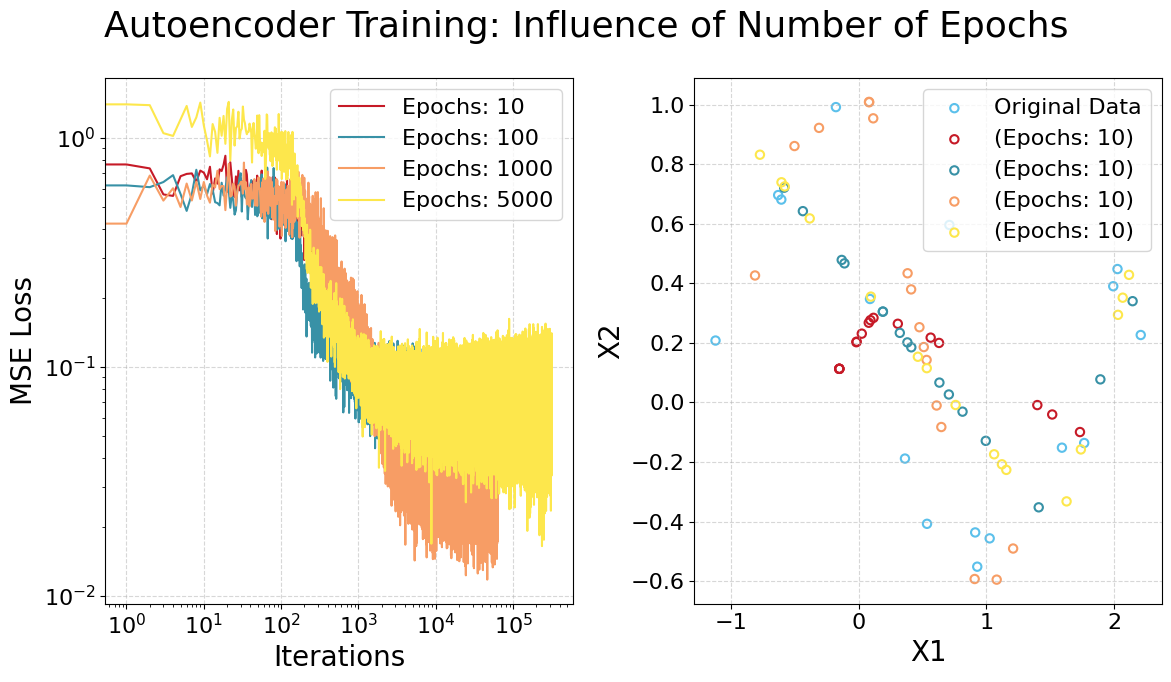

In [38]:
# Plot MSE loss for different number of epochs
title = "Autoencoder Training: Influence of Number of Epochs"
plot1_1(model_n_epochs, results_n_epochs, title, label="Epochs", label_index= 2 )



Increasing the training iterations by brute force provides mixed and inconsistent results. In the left diagramm, one can seet the MSE loss shows a reduction between 100 and 1000 training iterations and the reconstructed data appears to be in the same order of magnitude as the data, in contrast to the sample where we simply increased the number of training points. Even the best results show a very linear trend and fail to capture the profile of the two moon samples. In some cases, the models trained for 1000 or 5000 epochs approximate the curved behavior with extra diagonal lines. However, our hypothesis is that this will not improve much until we expand the size of our network, as it currently only has 2 layers of dimension 4. Let's first test whether this can be improved by increasing the number of samples the model trains simultaneously from mini_batch_size = 32 -> 256.

In [39]:
# 1 Investigate the influence of mini-batch-size given fixed other hyperparameters
hyperparameters_mbs = [(2000, 32, 1000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 64, 1000, 0.001, 4, 2),
                        (2000, 128, 1000, 0.001, 4, 2),
                        (2000, 256, 1000, 0.001, 4, 2)]

results_mbs = []
for params in hyperparameters_mbs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}")
    # Create model
    model_mbs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_mbs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_mbs.append((params, model_mbs.train_losses, model_mbs.outputs[-1]))

Training with training set size: 2000, n_epochs: 1000, mini batch size: 32


100%|██████████| 1000/1000 [00:38<00:00, 25.99it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 64


100%|██████████| 1000/1000 [00:21<00:00, 47.38it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 128


100%|██████████| 1000/1000 [00:12<00:00, 80.04it/s]


Training with training set size: 2000, n_epochs: 1000, mini batch size: 256


100%|██████████| 1000/1000 [00:10<00:00, 98.92it/s]


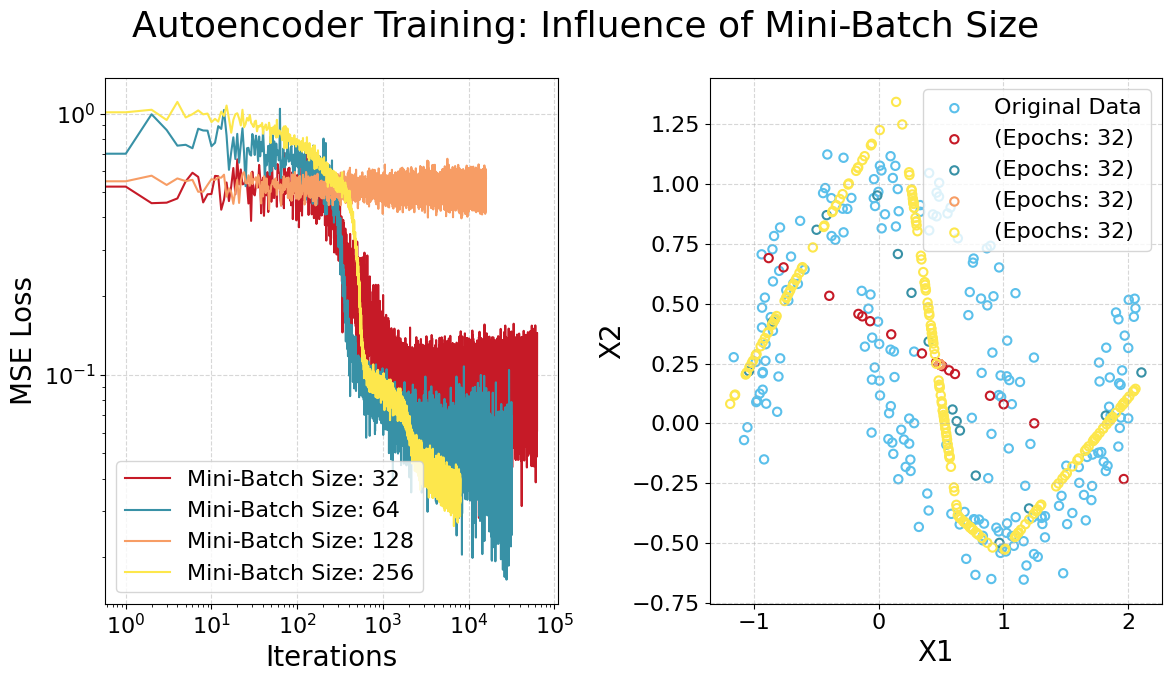

In [40]:
# Plot MSE loss for different mini-batch-sizes
title = "Autoencoder Training: Influence of Mini-Batch Size"
plot1_1(model_mbs, results_mbs, title, label="Mini-Batch Size", label_index= 1 )

As expected, increasing the test-points in every training iteration by using larger mini-batches provides inconsistent or at best marginally better results. Next we will test different network sizes. Since the data is relatively simple, increasing the number of layers beyond a certain extent will likely not provide significant results. Instead, it could cause issues due to vanishing gradients

In [41]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_lyrs = [(2000, 128, 2000, 0.001, 4, 2), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 4, 3),
                        (2000, 128, 2000, 0.001, 4, 4),
                        (2000, 128, 2000, 0.001, 4, 8)]

results_lyrs = []
for params in hyperparameters_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, layers: {params[5]}")
    # Create model
    model_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_lyrs.append((params, model_lyrs.train_losses, model_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 2


100%|██████████| 2000/2000 [00:24<00:00, 81.58it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 3


100%|██████████| 2000/2000 [00:29<00:00, 67.93it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 4


100%|██████████| 2000/2000 [00:34<00:00, 58.14it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, layers: 8


100%|██████████| 2000/2000 [00:53<00:00, 37.32it/s]


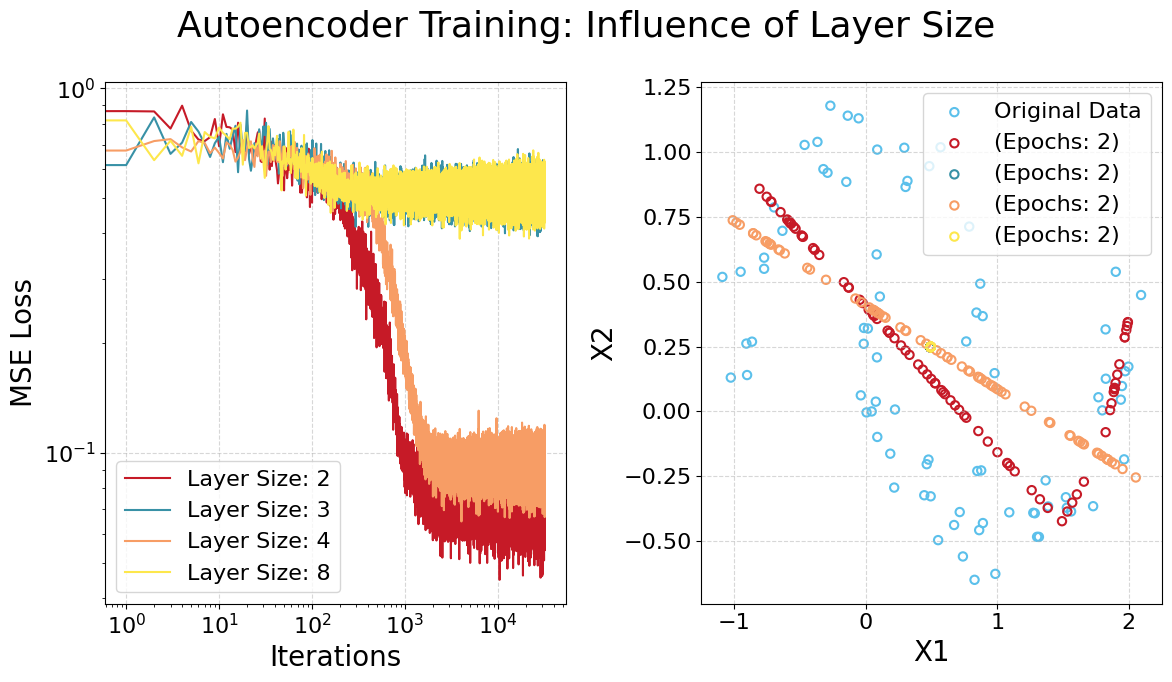

In [42]:
# Plot MSE loss for different layer-sizes
title = "Autoencoder Training: Influence of Layer Size"
plot1_1(model_lyrs, results_lyrs, title, label="Layer Size", label_index= 5 )

Indeed, increasing the number of layers doesn't correlate with better performance. However, wider layers are more robust against vanishing layers and learn more features such as the curves of the two moons, the gap between them, etc. Likely this is the defining parameter between a model which kind of understands what it should be doing and one which does what it needs to do.

In [ ]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_hsize = [(2000, 128, 2000, 0.001, 4, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 2000, 0.001, 8, 4),
                        (2000, 128, 2000, 0.001, 16, 4),
                        (2000, 128, 2000, 0.001, 32, 4)]

results_hsize = []
for params in hyperparameters_hsize:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_hsize = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_hsize.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_hsize.append((params, model_hsize.train_losses, model_hsize.outputs[-1]))

In [ ]:
# Plot MSE loss for different hidden-sizes
title = "Autoencoder Training: Influence of Hidden Size"
plot1_1(model_hsize, results_hsize, title, label="Hidden Size", label_index= 4 )

Indeed! Upon visual inspection, the models are learning the nuances of the two moons data, in particularl adapting to the gap between the two moons (hidden size: 32) and following the curves more accurately (hidden size: 8+). Now, we would like to refine the rest of the hyperparameters. For example, the Loss diagram shows that there is still more room to let the model converge, so we should increase the number of iterations it trains for.

In [ ]:
# 1 Investigate the influence of network-sizes given fixed other hyperparameters
hyperparameters_refine_n_epochs = [(2000, 128, 2000, 0.001, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 8000, 0.001, 16, 4),
                        (2000, 128, 10000, 0.001, 16, 4)]

results_refine_n_epochs = []
for params in hyperparameters_refine_n_epochs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_n_epochs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_n_epochs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_n_epochs.append((params, model_refine_n_epochs.train_losses, model_refine_n_epochs.outputs[-1]))

In [7]:
# Plot MSE loss for different hidden-sizes
title = "Autoencoder Training: Influence of Hidden Size"
plot1_1(model_refine_n_epochs, results_refine_n_epochs, title, label="Epochs", label_index= 2 )

NameError: name 'model_refine_n_epochs' is not defined

There's no noticeable improvement beyond 2000-4000 training epochs. Next we'll try softer and more aggressive learning rates.

In [109]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_lr = [(2000, 128, 4000, 0.1, 16, 4), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                        (2000, 128, 4000, 0.01, 16, 4),
                        (2000, 128, 4000, 0.001, 16, 4),
                        (2000, 128, 4000, 0.0001, 16, 4)]

results_refine_lr = []
for params in hyperparameters_refine_lr:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_lr = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_lr.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_lr.append((params, model_refine_lr.train_losses, model_refine_lr.outputs[-1]))

Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:43<00:00, 24.46it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:55<00:00, 22.82it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:53<00:00, 23.00it/s]


Training with training set size: 2000, n_epochs: 4000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 4000/4000 [02:56<00:00, 22.63it/s]


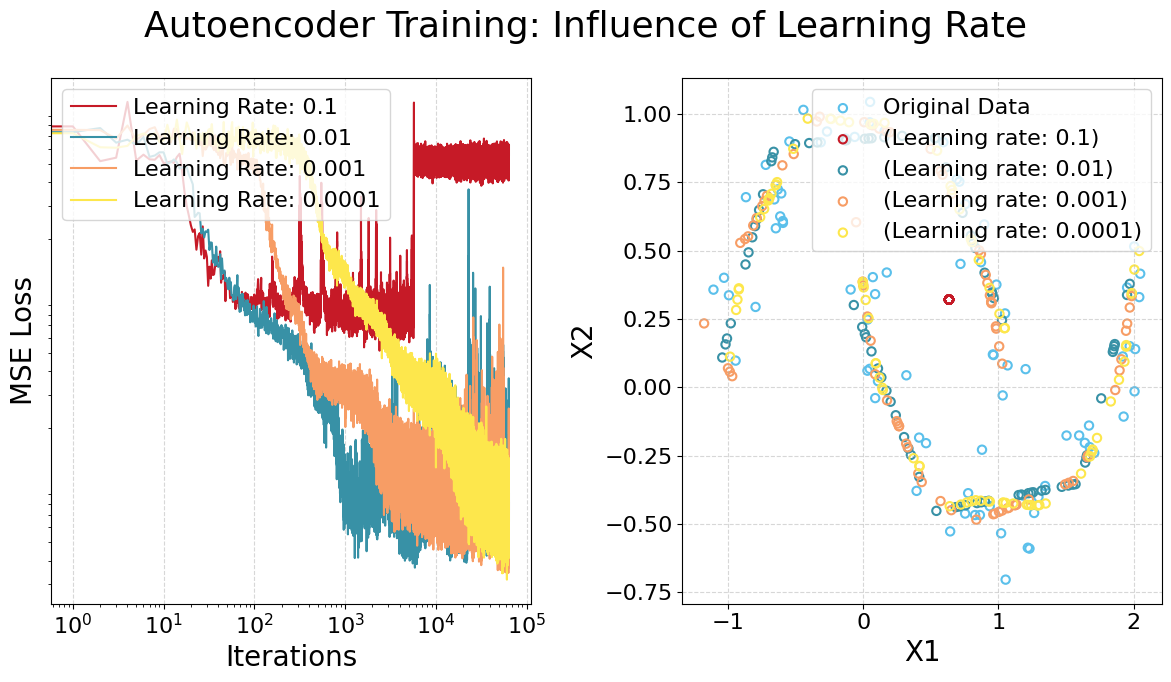

In [111]:
# Plot MSE loss for different learning rates
title = "Autoencoder Training: Influence of Learning Rate"
plot1_1(model_refine_lr, results_refine_lr, title, label="Learning rate", label_index= 3 )

An aggressive learning rate of 0.1 seems to break down at some point, while smaller learning rates do comparatively well and similar to each other, except that a learning rate of 0.0001 simply takes longer to get there compared to 0.01 and 0.001. One could implement a learning schedule, but I think for our purposes with simple data this would be overkill. Instead, we'll stick to a learning rate between 0.01 - 0.001. Now let's try to economize and cut corners where we may have initially overcompensated. For example, we chose 4 hidden layers because it worked best when there were 4 neurons each. Then we settled on 16 neurons each without adjusting the number of layers.

In [129]:
# 1 Investigate the influence of learning rates given fixed other hyperparameters
hyperparameters_refine_hs_lyrs = [(2000, 128, 2000, 0.005, 16, 4),
                                  (2000, 128, 2000, 0.005, 12, 4),
                                  (2000, 128, 2000, 0.005, 16, 3), # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
                                  (2000, 128, 2000, 0.005, 12, 3),
                                  (2000, 128, 2000, 0.005, 16, 2),
                                  (2000, 128, 2000, 0.005, 12, 2),
                                  #(2000, 128, 2000, 0.005, 8, 2),
                                  #(2000, 128, 2000, 0.005, 6, 2)
                                  ]

results_refine_hs_lyrs = []
for params in hyperparameters_refine_hs_lyrs:
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
    # Create model
    model_refine_hs_lyrs = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_refine_hs_lyrs.train_autoencoder(X_train, 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_refine_hs_lyrs.append((params, model_refine_hs_lyrs.train_losses, model_refine_hs_lyrs.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 4


100%|██████████| 2000/2000 [01:13<00:00, 27.13it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 4


100%|██████████| 2000/2000 [01:24<00:00, 23.76it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 3


...

100%|██████████| 2000/2000 [01:18<00:00, 25.38it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 2


100%|██████████| 2000/2000 [01:06<00:00, 29.85it/s]


Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 12, layers: 2


100%|██████████| 2000/2000 [01:07<00:00, 29.53it/s]


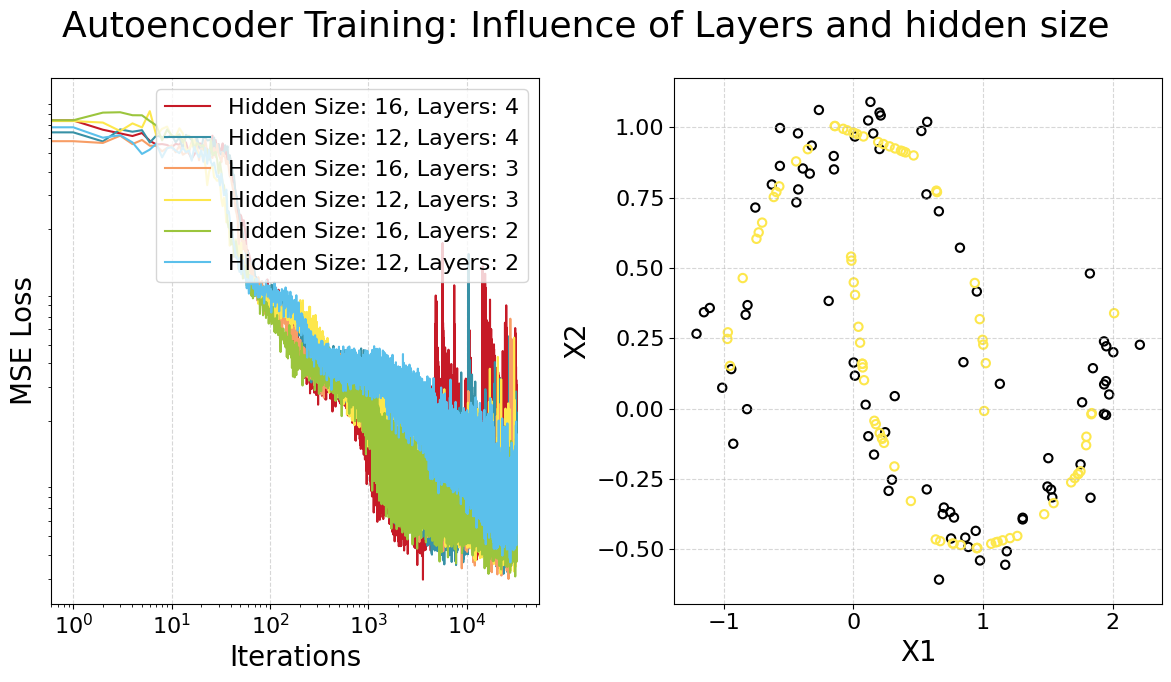

In [139]:
# Plot MSE loss for different learning rates
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Layers and hidden size", fontsize=26)
# Plot training losses
for res in results_refine_hs_lyrs:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Hidden Size: {params[4]}, Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog('log')
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_refine_hs_lyrs[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_refine_hs_lyrs)):
    if i in [1, 2, 0, 4, 5]:
        continue
    final_epoch, X_batch, decoded = results_refine_hs_lyrs[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Hidden size: {results_refine_hs_lyrs[i][0][4]}, Layers: {results_refine_hs_lyrs[i][0][5]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].legend()
plt.tight_layout()
plt.show()

While reducing the number of neurons and layers still yields recognizable results, the lines get smoother and smoother for a wider and slightly deeper architecture. We find the best combination of depth and width to be 3 layers of 16 neurons each.

---
### 1.2 Reconstruction with the same or different data sets

To evaluate the optimized parameters `(training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers) = (2000, 128, 2000, 0.005, 16, 3)`, we repeat training with the same or different datasets and evaluate the mean squared error and its variance.

We start by training the same model again with an identical data set. This is not expected to make a big difference in performance, since no 'additional' information about the distribution is provided.

In [7]:
params= (2000, 128, 2000, 0.005, 16, 3) # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers

#Make a list of Data sets:
#Train the model with the same data set again: 
sameSets = [(X_train, "X_train"), (X_train, "X_train"), (X_train, "X_train")]

results_sameSets = []
print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
for TS in sameSets:
    print(f"Training set: {TS[1]}")
    # Create model
    model_sameSets = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_sameSets.train_autoencoder(TS[0], 
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_sameSets.append((TS[1], params, model_sameSets.train_losses, model_sameSets.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 3
Training set: X_train


100%|██████████| 2000/2000 [00:29<00:00, 66.73it/s]


Training set: X_train


100%|██████████| 2000/2000 [00:30<00:00, 66.29it/s]


Training set: X_train


100%|██████████| 2000/2000 [00:30<00:00, 66.35it/s]


Set: Mean, Std
X_train: 0.0071 0.0161
X_train: 0.0088 0.0164
X_train: 0.0110 0.0169
Average MSE over all data sets: 0.0090 with a standard deviation of 0.0016


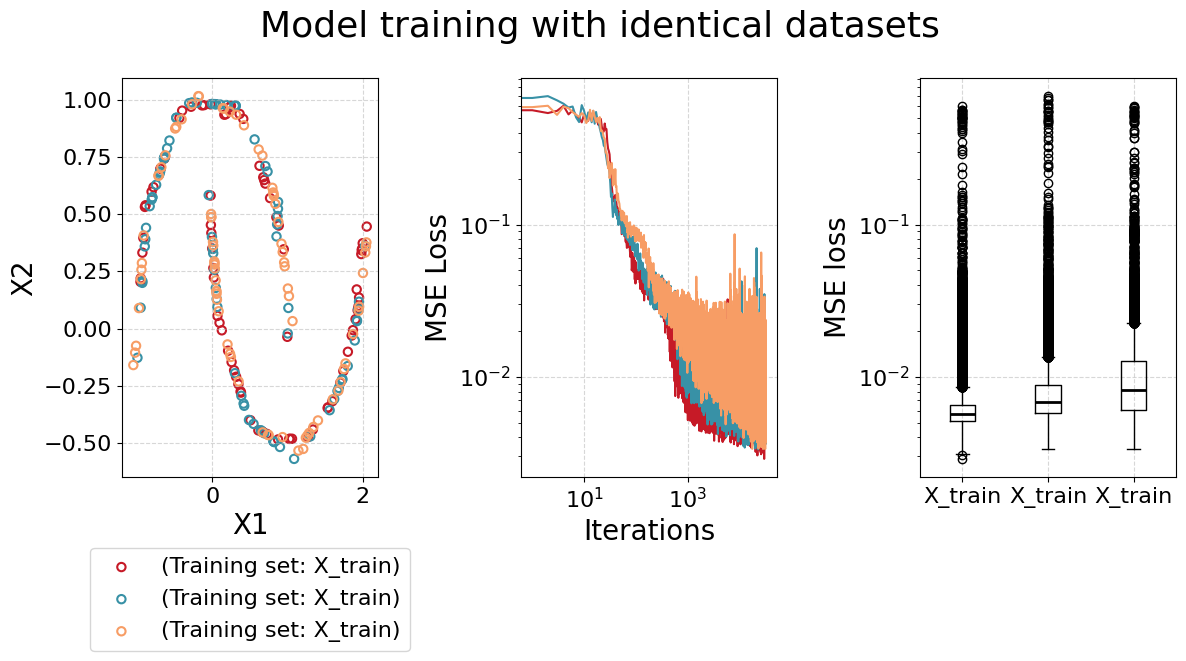

In [8]:
title= "Model training with identical datasets"
plot1_2(model_sameSets, results_sameSets, title)

Training with the same data set does not make a big difference in reconstruction quality of the models, as expected. 

The reconstructed data points look very similar and the MSE losses behave similarly. Overall, a mean MSE loss of ~0.009 is reached with a standard deviation of 0.001. 
Yet, outliers are possible when retraining the model.

In [9]:
#Make a list of Data sets:
def makeTS(n_samples=125000, noise=0.1, random_state=42):
    X, y = make_moons(n_samples= n_samples, noise= noise, random_state= random_state)
    X = torch.tensor(X, dtype=torch.float32)
    X_test, X_train = train_test_split(X, test_size=0.2, random_state=42)
    return X_train

n_sets = 3
diffSets = [(X_train, "X_train")]
for i in range(1,n_sets):
    X = makeTS()
    diffSets.append((X, f"X_{i}"))
#diffSets.append((X_train, "X_train"))

# Train the model with different data sets:
results_diffSets = []
print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}, hidden size: {params[4]}, layers: {params[5]}")
for TS in diffSets:
    print(f"Training set: {TS[1]}")
    # Create model
    model_diffSets = Autoencoder(input_size=2, 
                        bottleneck_size=1, 
                        hidden_size=params[4], 
                        layers=params[5])
    # Train model
    model_diffSets.train_autoencoder(TS[0], #!! the same model is trained again and again, no new model! (? still okay for )
                            training_set_size=params[0], 
                            mini_batch_size=params[1], 
                            n_epochs=params[2], 
                            learning_rate=params[3])
    # Save result
    results_diffSets.append((TS[1], params, model_diffSets.train_losses, model_diffSets.outputs[-1]))

Training with training set size: 2000, n_epochs: 2000, mini batch size: 128, hidden size: 16, layers: 3
Training set: X_train


100%|██████████| 2000/2000 [00:30<00:00, 66.37it/s]


Training set: X_1


100%|██████████| 2000/2000 [00:30<00:00, 66.23it/s]


Training set: X_2


100%|██████████| 2000/2000 [00:30<00:00, 66.15it/s]


Set: Mean, Std
X_train: 0.0098 0.0163
X_1: 0.0096 0.0194
X_2: 0.0080 0.0159
Average MSE over all data sets: 0.0092 with a standard deviation of 0.0008


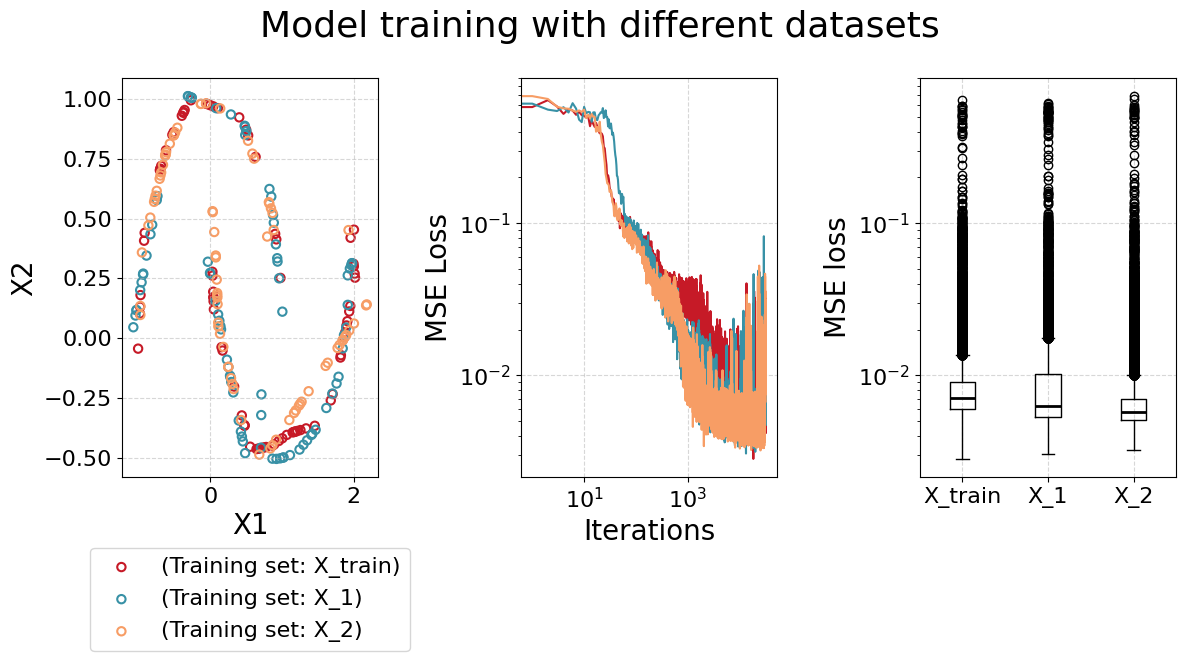

In [11]:
title= "Model training with different datasets"
plot1_2(model_diffSets, results_diffSets, title)

Training the model with different data sets results in visibly different reconstructed distributions. 

However, the MSE losses have similar values and standard deviations (~0.009 and ~0.001) compared to re-training with identical data sets. The overall shape of two moons is still clearly visible.

---
### 1.3 Visualising the code distribution and generating samples

We start by training a model on the original training data with the defined hyperparameters (`params`). We then use train a GaussianMixture Model with 2 components. (More components lead to overfitting of the 1D-data set.) Using this GMM, new samples are generated and decoded. 

See Figure below. 

In [51]:
#Train model with ideal parameters (params) and X_train:
# Create model
model_Z = Autoencoder(input_size=2, bottleneck_size=1, hidden_size=params[4], layers=params[5])
# Train model
model_Z.train_autoencoderZ(X_train,training_set_size=params[0], mini_batch_size=params[1], n_epochs=params[2], learning_rate=params[3]) 
_, _, decoded, encoded = model_Z.outputs[-1]
z = encoded[:,0].detach().numpy()
x,y = decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy()

100%|██████████| 2000/2000 [00:32<00:00, 62.47it/s]


In [52]:
#Fit GMM:
z_ = z.reshape(-1, 1)
gmm = GaussianMixture(n_components = components).fit(z_)

#Get parameters
mean = gmm.means_
covs  = gmm.covariances_
weights = gmm.weights_

#Generate samples:
x_hat, x_gen = model_Z.gmmGenerate(2) #see class implementation

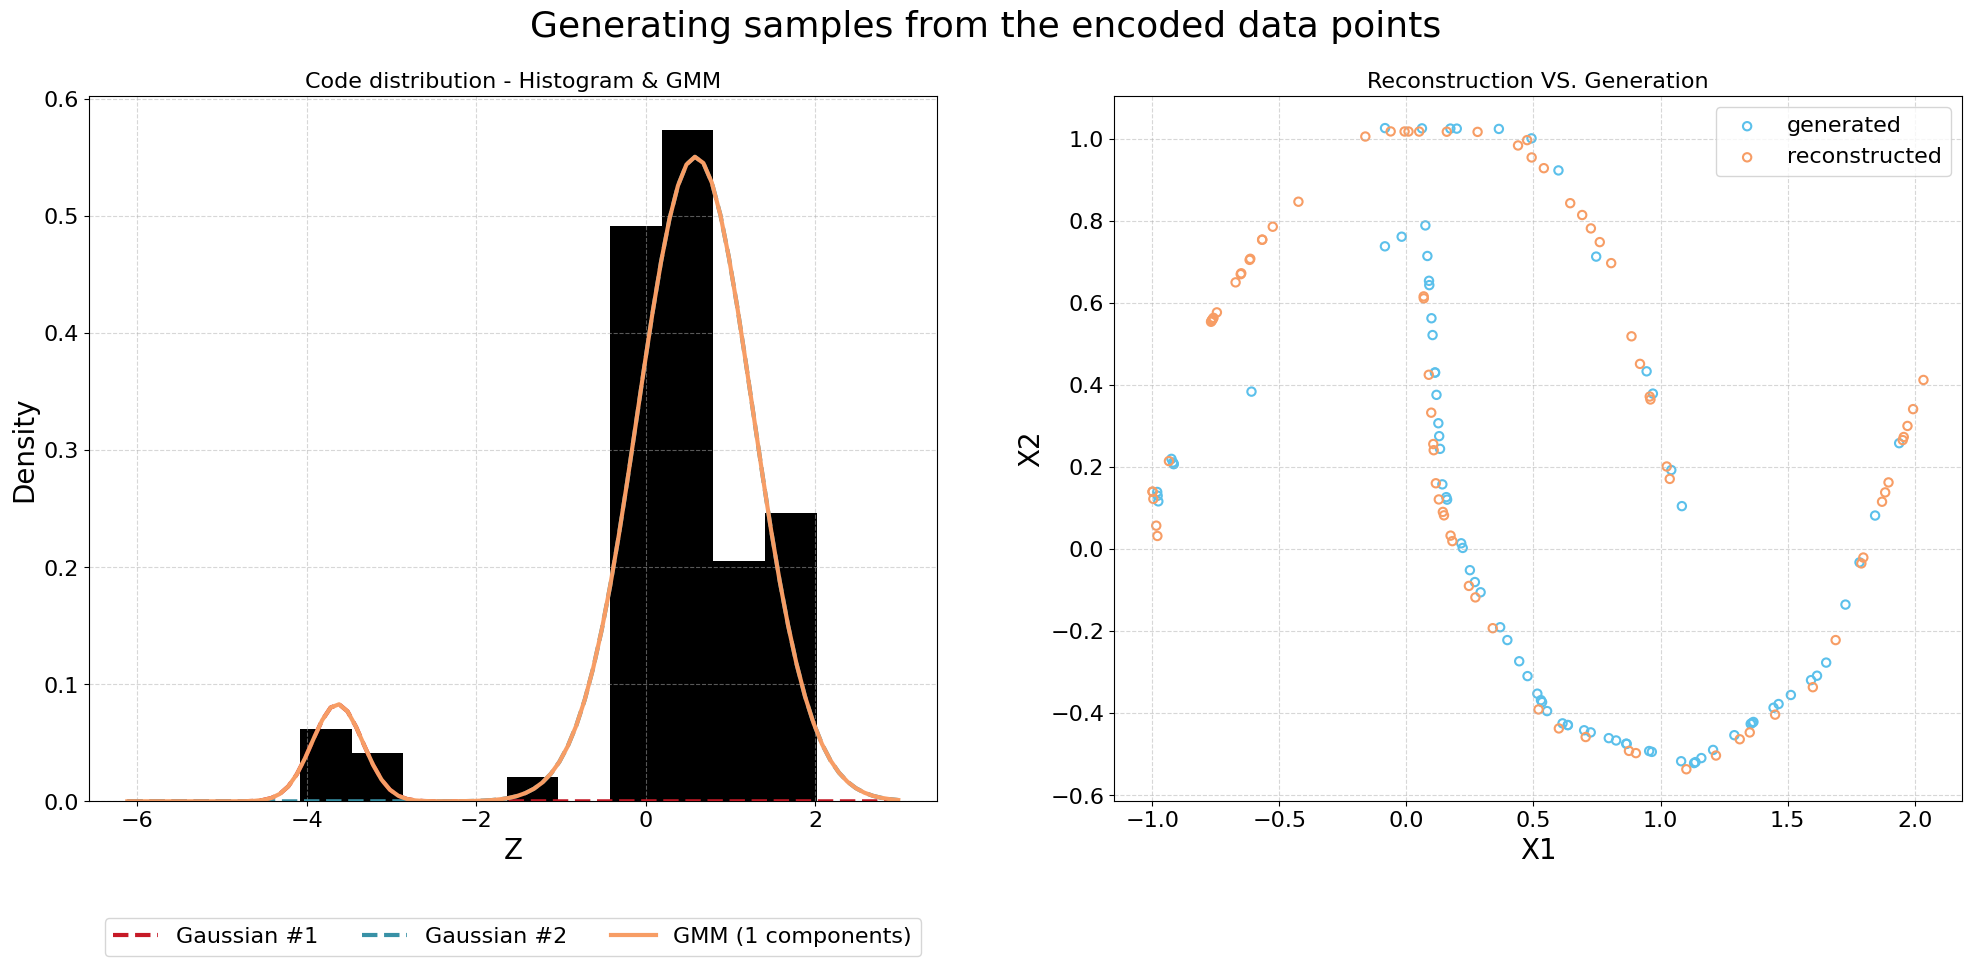

In [53]:
#Visualize Code distribution: 

#Calculate Histogram parameters:
bin_counts, bin_edges = np.histogram(z)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_widths = np.diff(bin_edges)
bin_density = bin_counts/(np.sum(bin_counts)*bin_widths) # P(bin) = Nl / (H*h)

fig, axes = plt.subplots(1, 2, figsize= (20,10))
fig.suptitle("Generating samples from the encoded data points", fontsize=26)

#Plot Density Histogram with GMM:
a = 0
axes[a].bar(bin_centers, bin_density, width=bin_widths, align='center', color= 'k')
axes[a].set_title("Code distribution - Histogram & GMM", fontsize= 16)
z_axis = np.arange((np.min(z)*1.5), (np.max(z)*1.5), 0.1)
y_all = np.zeros((len(z),len(z_axis)))
for n in range(components):
    y_axis = norm.pdf(z_axis, float(mean[n][0]), np.sqrt(float(covs[n][0][0])))*weights[n] # 1st gaussian
    axes[a].plot(z_axis, y_axis, lw=3,ls='dashed', label=f"Gaussian #{n+1}")
    y_all += y_axis
axes[a].plot(z_axis, y_all[0], lw=3, c='C2', label=f"GMM ({n} components)")
axes[a].set_xlabel(f"Z", fontsize=20)
axes[a].set_ylabel(f"Density", fontsize=20)
axes[a].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols= 3)

'''
# Plot final reconstruction
axes[0].scatter(x,y, color = colors[0])
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
#axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15))
axes[0].set_title("Reconstructed data", fontsize= 16)
'''
# Plot final reconstruction
b = 1
axes[b].scatter(x_gen[:,0].detach().numpy(),x_gen[:,1].detach().numpy(),label=f"generated", color = colors[5])
#axes[b].scatter(x_hat[:,0].detach().numpy(), x_hat[:,1].detach().numpy(),label=f"reconstructed", color = colors[2])
axes[b].scatter(x, y,label=f"reconstructed", color = colors[2])
axes[b].set_xlabel("X1")
axes[b].set_ylabel("X2")
axes[b].legend()
axes[b].set_title("Reconstruction VS. Generation", fontsize= 16)

plt.tight_layout()
plt.show()

Notably, the largest bins in the code distribution are usually between the z-coordinates roughly relate  to the maximum number of data point in the true distribution. 

The quality of the generated data is visibly worse than the reconstructed data with more outliers and point connecting the two moons horizontally, in some cases.

Still, it also heavily depends on how accurate the reconstructed data points fit the true distribution. 

---
### 1.4 Testing AE with larger noise

We use the original autoencoder set-up (`params`) with the original training set `X_train` with noise level 0.1. Then, we evaluate the AE performance with a noisy test set (noise level 0.2). 

The reconstruction quality at a higher noise level is visibly worse. This makes sense, as the model is not trained for data sets with a larger variance and will hence produce inaccurate results.

In [77]:
#Train model with ideal parameters (params) and X_train (noise 0.1):
# Create model
model_tryNoise = Autoencoder(input_size=2, bottleneck_size=1, hidden_size=params[4], layers=params[5])
# Train model
model_tryNoise.train_autoencoder(X_train,training_set_size=params[0], mini_batch_size=params[1], n_epochs=params[2], learning_rate=params[3]) 
_, _, decoded = model_tryNoise.outputs[-1]
#x,y = decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy()

100%|██████████| 2000/2000 [00:32<00:00, 62.37it/s]


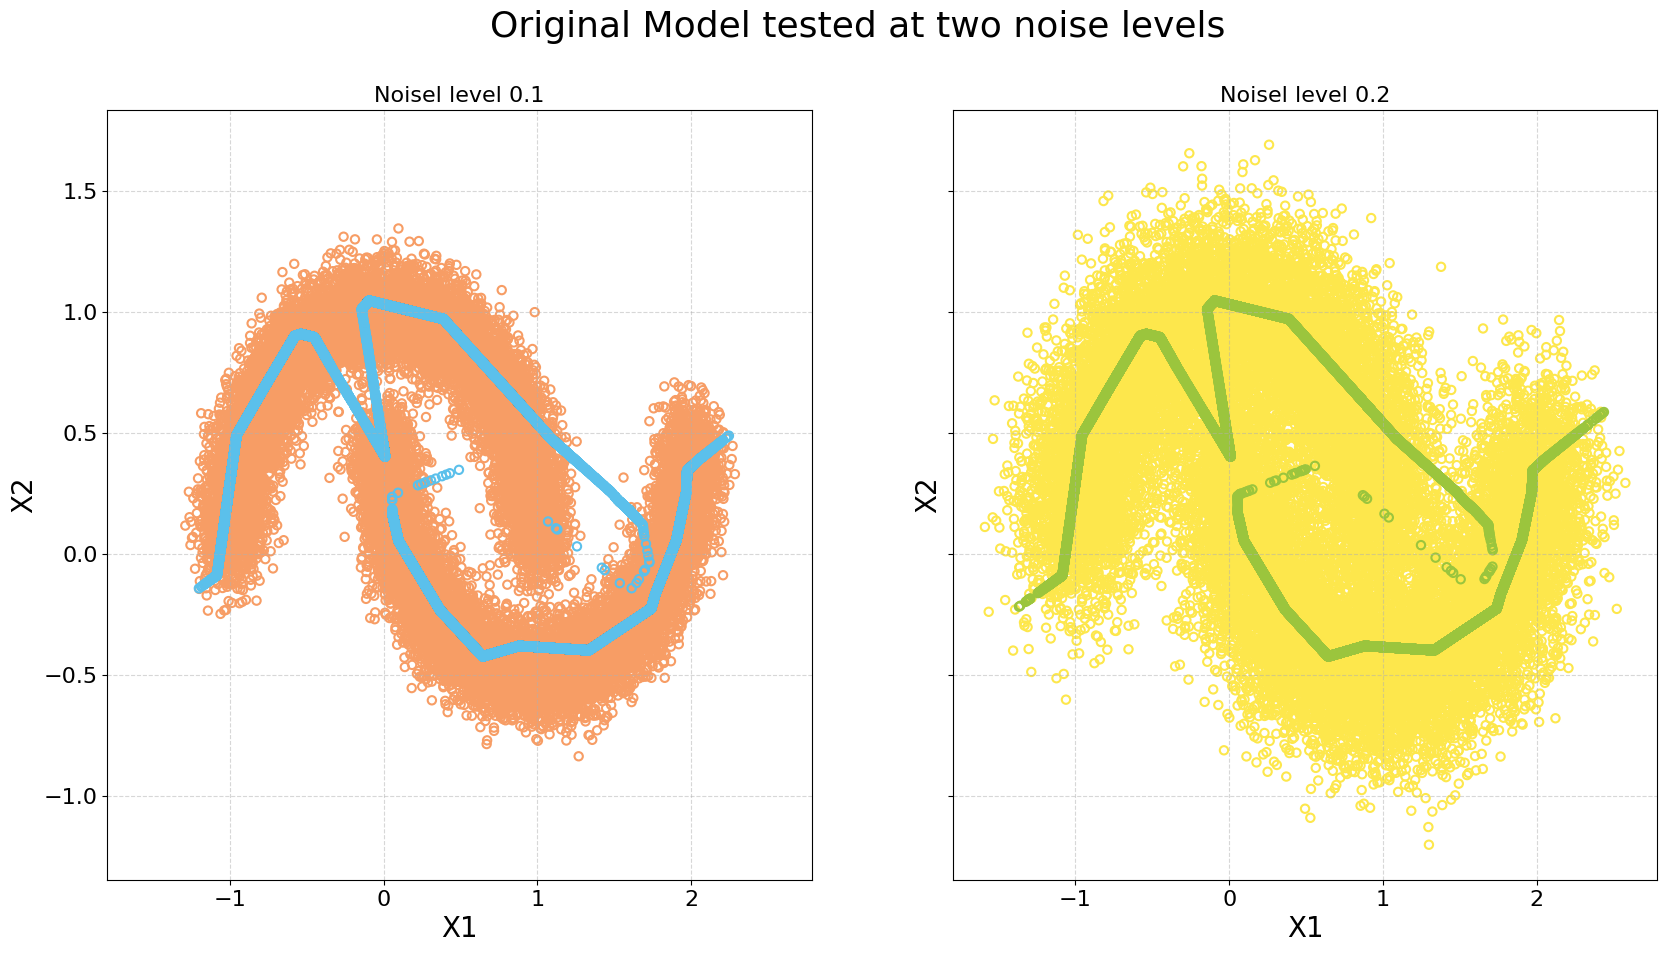

In [82]:
X_Noisy = makeTS(noise=0.2)
X_Noisy = X_Noisy.detach().clone()

Noise = model_tryNoise.forward(X_Noisy)
NoNoise = model_tryNoise.forward(X_train)

# Plot:
fig, axes = plt.subplots(1, 2, figsize= (20,10), sharex= True, sharey= True)
fig.suptitle("Original Model tested at two noise levels", fontsize=26)

axes[0].scatter(X_train[:,0].detach().numpy(), X_train[:,1].detach().numpy(),label=f"X_train", color = colors[2])
axes[0].scatter(NoNoise[:,0].detach().numpy(), NoNoise[:,1].detach().numpy(),label=f"Reconstruction", color = colors[5])
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].set_title("Noisel level 0.1", fontsize= 16)
axes[1].scatter(X_Noisy[:,0].detach().numpy(), X_Noisy[:,1].detach().numpy(),label=f"X_Noisy", color = colors[3])
axes[1].scatter(Noise[:,0].detach().numpy(), Noise[:,1].detach().numpy(),label=f"Reconstruction", color = colors[4])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].set_title("Noisel level 0.2", fontsize= 16)
#plt.title(, fontsize= 16)

#plt.tight_layout()
plt.show()

---
### 1.5 Training AE with larger noise


In [71]:
#Train model with ideal parameters (params) and X_train (noise 0.1):
# Create model
model_Noisy = Autoencoder(input_size=2, bottleneck_size=1, hidden_size=params[4], layers=params[5])
# Train model
model_Noisy.train_autoencoder(X_Noisy,training_set_size=params[0], mini_batch_size=params[1], n_epochs=params[2], learning_rate=params[3]) 
_, _, NoiseT = model_Noisy.outputs[-1]
#x,y = decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy()

100%|██████████| 2000/2000 [00:31<00:00, 64.15it/s]


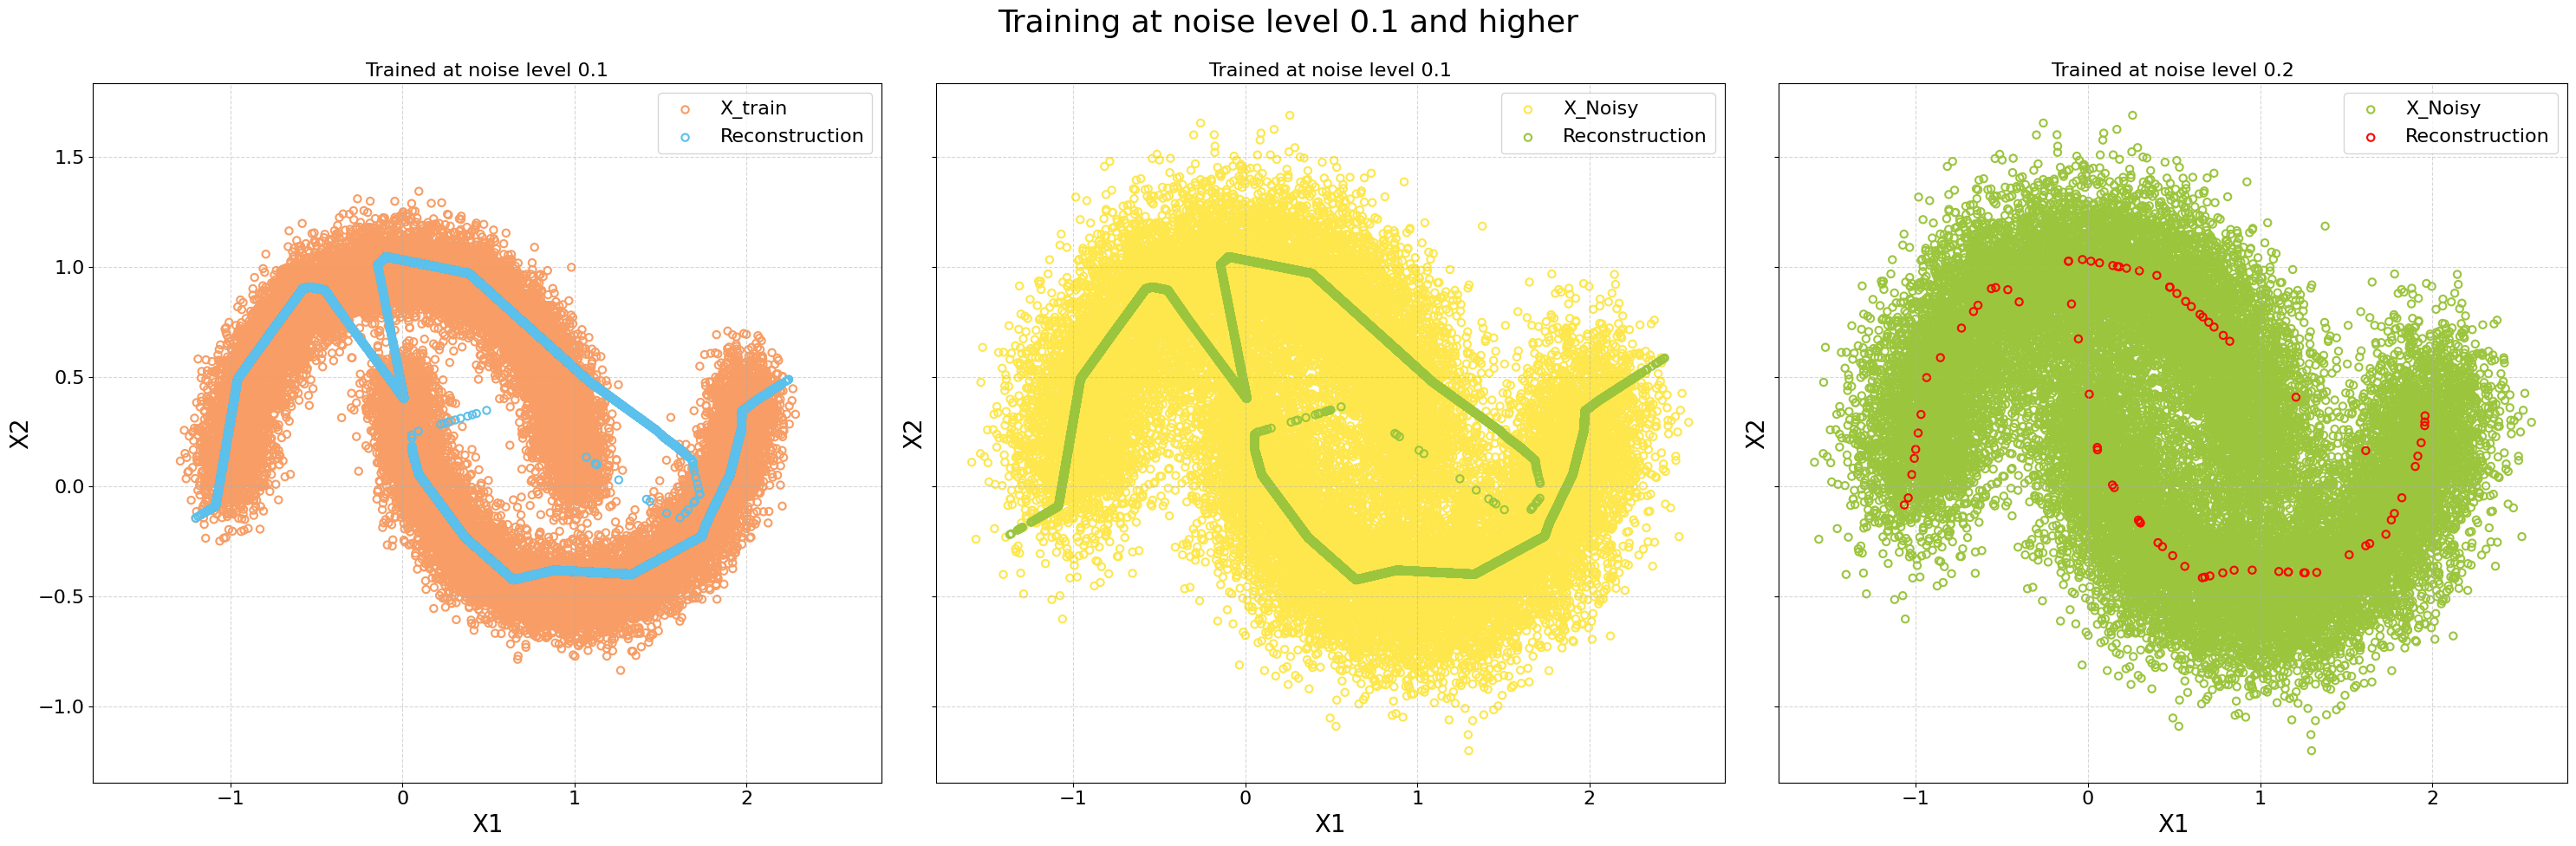

In [90]:
# Plot:
NoiseT = decoded 
fig, axes = plt.subplots(1, 3, figsize= (30,10), sharex= True, sharey= True)
fig.suptitle("Training at noise level 0.1 and higher", fontsize=26)

axes[0].scatter(X_train[:,0].detach().numpy(), X_train[:,1].detach().numpy(),label=f"X_train", color = colors[2])
axes[0].scatter(NoNoise[:,0].detach().numpy(), NoNoise[:,1].detach().numpy(),label=f"Reconstruction", color = colors[5])
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].set_title("Trained at noise level 0.1", fontsize= 16)
axes[0].legend()
axes[1].scatter(X_Noisy[:,0].detach().numpy(), X_Noisy[:,1].detach().numpy(),label=f"X_Noisy", color = colors[3])
axes[1].scatter(Noise[:,0].detach().numpy(), Noise[:,1].detach().numpy(),label=f"Reconstruction", color = colors[4])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].set_title("Trained at noise level 0.1", fontsize= 16)
axes[1].legend()

axes[2].scatter(X_Noisy[:,0].detach().numpy(), X_Noisy[:,1].detach().numpy(),label=f"X_Noisy", color = colors[4])
axes[2].scatter(NoiseT[:,0].detach().numpy(), NoiseT[:,1].detach().numpy(),label=f"Reconstruction", color = 'red')
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")
axes[2].set_title("Trained at noise level 0.2", fontsize= 16)
axes[2].legend()

plt.tight_layout()
plt.show()

The reconstructed data resembles the center line of the noisy data much more, when the model is trained at the according noise level. 